In [2]:
import pandas as pd
import numpy as np
import marimo as mo
import matplotlib.pyplot as plt
from hapiclient import hapi
from datetime import datetime, timedelta
from scipy.optimize import brentq
import time
from sklearn.mixture import GaussianMixture

In [3]:
R_sun, AU = 695_700.0, 1.495978707e8     # km
r_0 = 20 * R_sun

In [4]:
lampani_set = pd.read_csv('./data/lampani_set_with_celias.csv')
lampani_set.dropna(inplace=True)

$$\sigma_- := \arctan\!\left(\sqrt{-\dfrac{\gamma}{a}}\,(v_0-w)\right) $$

$$t^*_- = \frac{\sigma_-}{\sqrt{-a\gamma}} \quad (a<0).$$

# 3D (width, mass, $v_0$) joint empirical distribution

In [5]:
columns = [
    "Date", "Time", "Central_PA", "Width", "Linear_Speed", 
    "2nd_order_speed_initial", "2nd_order_speed_final", "2nd_order_speed_20R", 
    "Accel", "Mass", "Kinetic_Energy", "MPA", "Remarks"
]

cdaw = pd.read_csv(
    "./data/univ_all.txt",
    sep=r'\s+',            # Split by one or more spaces
    skiprows=3,            # Skip the title and the 2-line header
    names=columns,         # Manually supply clean column names
    on_bad_lines='skip',   # Defends against footer notes if any exist
    index_col=False,
    engine='python'
)

cdaw = cdaw[cdaw['Mass'] != "-------"][['Width', 'Linear_Speed', 'Mass']]

cdaw['Mass'] = cdaw['Mass'].str.replace('*', '', regex=False)

cdaw['Mass'] = pd.to_numeric(cdaw['Mass'], errors='coerce')
cdaw['Linear_Speed'] = pd.to_numeric(cdaw['Linear_Speed'], errors='coerce')

cdaw

C:\Users\Lukas\AppData\Local\Temp\ipykernel_4708\2408137890.py:7: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  cdaw = pd.read_csv(


,Width,Linear_Speed,Mass
3,37,267.0,7.100000e+13
4,27,262.0,3.000000e+14
5,24,30.0,1.000000e+14
6,28,60.0,4.400000e+13
7,56,69.0,6.300000e+14
...,...,...,...
40364,59,200.0,6.400000e+13
40365,65,364.0,3.100000e+15
40366,69,198.0,1.700000e+14
40368,36,563.0,8.800000e+14


In [6]:
data = cdaw.copy()
data['log_mass'] = np.log10(data['Mass'])
data.dropna(inplace=True)

X = data[['Linear_Speed', 'log_mass', 'Width']].to_numpy()

mu_cdaw, sd_cdaw = X.mean(0), X.std(0)
Xs = (X - mu_cdaw) / sd_cdaw

gmm_cdaw = GaussianMixture(n_components=8, covariance_type='full', random_state=0)
gmm_cdaw.fit(Xs)

samp, _ = gmm_cdaw.sample(50_000)
samp = samp * sd_cdaw + mu_cdaw
synth = pd.DataFrame(samp, columns=['v0', 'log_mass', 'width'])
synth['mass'] = 10 ** synth['log_mass']
synth = synth[['v0', 'mass', 'width']]

In [7]:
cdaw_log = cdaw.copy()
cdaw_log['log_mass'] = np.log10(cdaw_log['Mass'])

synth_corr = synth.copy()
synth_corr['log_mass'] = np.log10(synth_corr['mass'])   # build it here

corr_cdaw  = cdaw_log[['Linear_Speed', 'log_mass', 'Width']].corr().to_numpy()
corr_synth = synth_corr[['v0', 'log_mass', 'width']].corr().to_numpy()

# two-Gaussian w PDF and $\rho$ PDF

In [8]:
celias_w_rho = pd.read_csv('./data/celias_w_rho_daily.csv')

In [9]:
d = celias_w_rho.dropna(subset=['w','rho']).copy()
d = d[(d['w'].between(150,1200)) & (d['rho'] > 0)]
d['log_rho'] = np.log10(d['rho'])

X_wr = d[['w', 'log_rho']].to_numpy()
print("fit shape:", X_wr.shape)            # must be (N, 2)

mu_wr = X_wr.mean(0)                        # shape (2,)
sd_wr = X_wr.std(0)                         # shape (2,)
Xs_wr = (X_wr - mu_wr) / sd_wr

for k in (1, 2, 3, 4):
    g = GaussianMixture(k, covariance_type='full', random_state=0).fit(Xs_wr)
    print(f"k={k}  BIC={g.bic(Xs_wr):.0f}")

gmm_wr = GaussianMixture(3, covariance_type='full', random_state=0).fit(Xs_wr)
print("means shape:", gmm_wr.means_.shape) # must be (2, 2)

fit shape: (3227, 2)
k=1  BIC=17192
k=2  BIC=16428
k=3  BIC=16347
k=4  BIC=16323
means shape: (3, 2)


In [10]:
def sample_w_rho(n, rng=np.random.default_rng(0)):
    s, _ = gmm_wr.sample(n)                 # (n, 2)
    s = np.asarray(s) * sd_wr + mu_wr       # (2,) vectors, broadcasts correctly
    out = pd.DataFrame(s, columns=['w', 'log_rho'])
    out['rho'] = 10 ** out['log_rho']
    out = out[(out['w'].between(150,1200)) & (out['rho'].between(0,200))]
    return out[['w','rho']].reset_index(drop=True)

synth_w_rho = sample_w_rho(50_000)

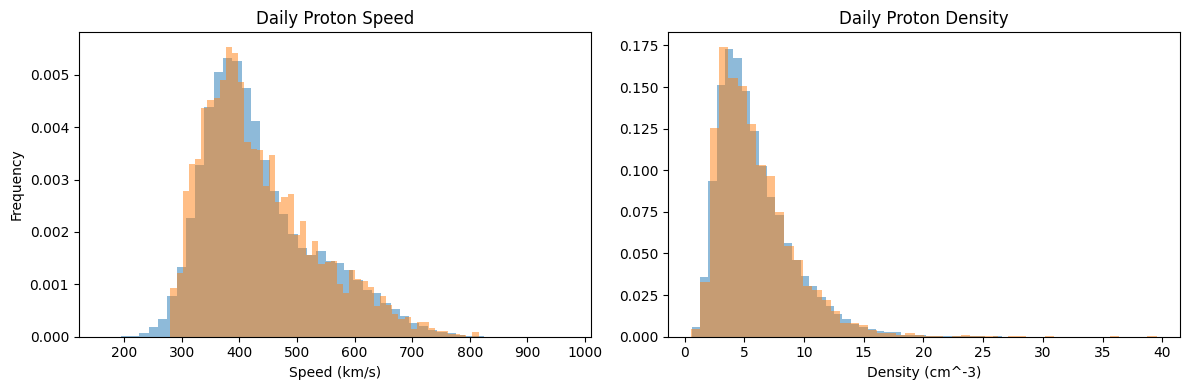

In [11]:
fig2, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

axs[0].hist(synth_w_rho.w, bins=50, alpha=0.5, density=True)
axs[0].hist(celias_w_rho.w, bins=50, alpha=0.5, density=True)
axs[0].set_title('Daily Proton Speed')
axs[0].set_xlabel('Speed (km/s)')
axs[0].set_ylabel('Frequency')

axs[1].hist(synth_w_rho.rho, bins=50, alpha=0.5, density=True)
axs[1].hist(celias_w_rho.rho, bins=50, alpha=0.5, density=True)
axs[1].set_title('Daily Proton Density')
axs[1].set_xlabel('Density (cm^-3)')

plt.tight_layout()
plt.show()

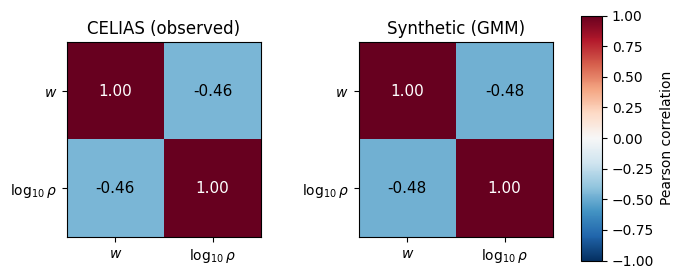

In [12]:
labels_wr = [r'$w$', r'$\log_{10}\rho$']

corr_real_wr  = celias_w_rho[['w', 'rho']].corr().to_numpy()
corr_synth_wr = synth_w_rho[['w', 'rho']].corr().to_numpy()

figga, axes = plt.subplots(1, 2, figsize=(7, 3.5))
titles = ['CELIAS (observed)', 'Synthetic (GMM)']
mats = [corr_real_wr, corr_synth_wr]

for axxx, mat, title in zip(axes, mats, titles):
    im = axxx.imshow(mat, vmin=-1, vmax=1, cmap='RdBu_r')
    axxx.set_xticks(range(len(labels_wr)))
    axxx.set_yticks(range(len(labels_wr)))
    axxx.set_xticklabels(labels_wr)
    axxx.set_yticklabels(labels_wr)
    axxx.set_title(title)

    for i in range(len(labels_wr)):
        for j in range(len(labels_wr)):
            val = mat[i, j]
            color = 'white' if abs(val) > 0.6 else 'black'
            axxx.text(j, i, f'{val:.2f}', ha='center', va='center',
                     color=color, fontsize=11)

figga.subplots_adjust(right=0.82, wspace=0.5)
cbar_axx = figga.add_axes([0.86, 0.15, 0.03, 0.7])
figga.colorbar(im, cax=cbar_axx, label='Pearson correlation')

plt.show()

# Solve for $a$ from napoletano set
## Family 4

In this family we assume $v_0 > w$, with

$$r(t)=\begin{cases}
\displaystyle wt+r_0+\dfrac{1}{\gamma}\ln\!\big(S_-\cos(\sqrt{-a\gamma}\,t-\sigma_-)\big), & 0\le t\le t^*_- \\
\displaystyle \Big(w-\sqrt{-\dfrac{a}{\gamma}}\Big)t+r_0-\dfrac{1}{\gamma}\!\left[\ln\!\Big(\frac{e^{\,-2(\sqrt{-a\gamma}\,t-\sigma_-)}+1}{2S_-}\Big)-\sigma_-\right], & t> t^*_-
\end{cases}$$

where:
$$
\sigma_- := \arctan\!\Big(\sqrt{-\dfrac{\gamma}{a}}\,(v_0-w)\Big), \qquad
S_- := \sqrt{\dfrac{a-\gamma(v_0-w)^2}{a}} \qquad (a<0)
$$
and
$$
t^*_- = \frac{\sigma_-}{\sqrt{-a\gamma}} \quad (a<0)
$$
we can write it in full

$$r(t)=\begin{cases}
\displaystyle wt+r_0+\frac{1}{\gamma}\ln\!\left(\sqrt{\frac{a-\gamma(v_0-w)^2}{a}}\,\cos\!\left(\sqrt{-a\gamma}\,t-\arctan\!\left(\sqrt{-\frac{\gamma}{a}}\,(v_0-w)\right)\right)\right), & 0\le t\le t^*_- \\[2ex]
\displaystyle \left(w-\sqrt{-\frac{a}{\gamma}}\right)t+r_0-\frac{1}{\gamma}\left[\ln\!\left(\frac{e^{-2\left(\sqrt{-a\gamma}\,t-\arctan\left(\sqrt{-\frac{\gamma}{a}}\,(v_0-w)\right)\right)}+1}{2\sqrt{\dfrac{a-\gamma(v_0-w)^2}{a}}}\right)-\arctan\!\left(\sqrt{-\frac{\gamma}{a}}\,(v_0-w)\right)\right], & t> t^*_-
\end{cases}$$

First branch is for **Super-wind (↘)**, valid time domain $\langle0, t_{-}^*\rangle$

Second branch is for **Cross-wind (↘)**, valid time domain $(t_{-}^*, \infty)$

In [13]:
def r_F4(t, a, v0, w, gamma):
    # a<0, v0>w ; t in SECONDS, speeds km/s, gamma 1/km
    s      = np.sqrt(-a * gamma)
    sigma  = np.arctan(np.sqrt(-gamma / a) * (v0 - w))
    t_star = sigma / s
    S      = np.sqrt((a - gamma * (v0 - w)**2) / a)
    if t <= t_star:                                   # branch 1: Super↘
        return w*t + r_0 + (1/gamma) * np.log(S * np.cos(s*t - sigma))
    else:                                             # branch 2: Cross↘
        e = np.exp(-2 * (s*t - sigma))
        return (w - np.sqrt(-a/gamma))*t + r_0 - (1/gamma)*(np.log((e+1)/(2*S)) - sigma)

def solve_a_F4(TT, v0, w, gamma, a_lo=-5e-3, a_hi=-1e-12):
    t = TT                              # hours -> seconds
    g = lambda a: r_F4(t, a, v0, w, gamma) - AU
    try:
        glo, ghi = g(a_lo), g(a_hi)
    except (ValueError, FloatingPointError):
        return np.nan                                 # domain blew up
    if not np.isfinite(glo) or not np.isfinite(ghi) or glo*ghi > 0:
        return np.nan                                 # no sign change -> reject
    return brentq(g, a_lo, a_hi)

In [14]:
f4 = lampani_set[lampani_set['v_r'] > lampani_set['w']].copy()
f4['Transit_time'] = f4['Transit_time'] * 3600

M_P = 1.6726e-24 # proton mass
CM3_PER_KM3 = 1e15 # 1 km^3 is 1e15 cm^3

rho_mass = f4['rho'] * M_P * CM3_PER_KM3
f4['gamma'] = 100 * (f4['A'] * rho_mass) / f4['Mass']

f4['gamma'].describe()

count    1.400000e+02
mean     6.935731e-08
std      2.112820e-07
min      1.098805e-09
25%      1.156223e-08
50%      2.260500e-08
75%      4.399175e-08
max      2.212630e-06
Name: gamma, dtype: float64

In [15]:
f4['a'] = f4.apply(lambda r: solve_a_F4(r['Transit_time'], r['v_r'],
                                     r['w'], r['gamma']), axis=1)
print("solved:", f4['a'].notna().sum(), "of", len(f4))
print("rejected:", f4['a'].isna().sum())

solved: 79 of 140
rejected: 61


In [16]:
a = f4['a'].dropna()
a.describe()

count    79.000000
mean     -0.002057
std       0.001111
min      -0.004838
25%      -0.002718
50%      -0.001959
75%      -0.001231
max      -0.000155
Name: a, dtype: float64

In [17]:
gam = f4.loc[a.index, 'gamma']
dv_f4  = f4.loc[a.index, 'v_r'] - f4.loc[a.index, 'w']
drag = gam * dv_f4**2
ratio = (-a) / drag
ratio[(ratio >= 0.01) & (ratio <= 10)]

2      0.371841
6      1.447613
8      1.770132
9      0.045747
10     0.222814
         ...   
155    0.068673
156    0.452063
157    0.368076
160    0.435315
163    0.572791
Length: 75, dtype: float64

In [18]:
log_a = np.log10(-a)            # all 79 (or 79 minus any proven-spurious)
print("log-space outliers (|z|>3):")
z = (log_a - log_a.mean())/log_a.std()
print(f4.loc[a.index][np.abs(z) > 3][['v_r','w','gamma','a']])

log-space outliers (|z|>3):
        v_r           w         gamma         a
145  544.82  337.583333  4.019736e-08 -0.000155


### log-normal distribution of $\log_{10}|a|$ for family 4
$$
\log_{10}|a| \sim \text{Lognormal}(\mu, \sigma^2)
$$

In [19]:
rng = np.random.default_rng(0)

log_abs_a = np.log10(-a.to_numpy())
mu_a, sd_a = log_abs_a.mean(), log_abs_a.std()
synth_a_f4 = -(10 ** rng.normal(mu_a, sd_a, 10000))

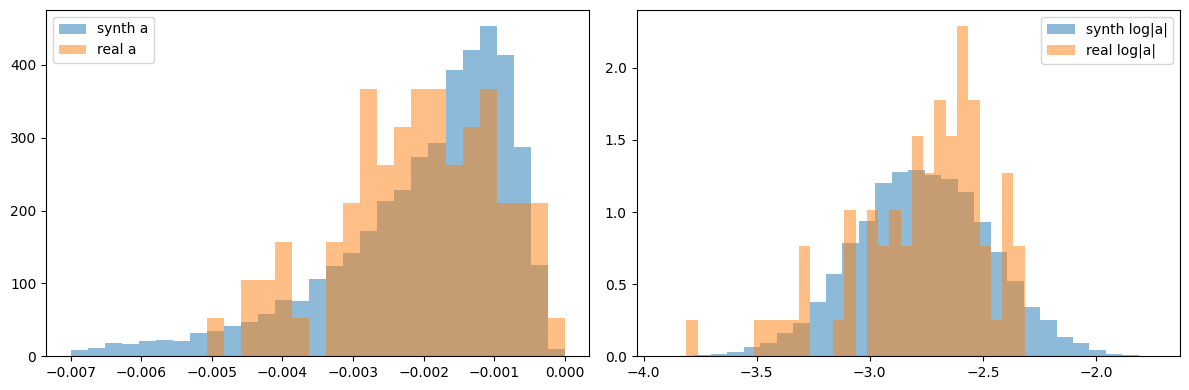

In [20]:
fig3, axs2 = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

bins_f4 = np.linspace(-0.007, 0, 30)
axs2[0].hist(synth_a_f4, bins=bins_f4, alpha=0.5, density=True, label='synth a')
axs2[0].hist(a, bins=bins_f4, alpha=0.5, density=True, label='real a')

axs2[1].hist(np.log10(-synth_a_f4), bins=30, alpha=0.5, density=True, label='synth log|a|')
axs2[1].hist(log_abs_a, bins=30, alpha=0.5, density=True, label='real log|a|')

axs2[1].legend()
axs2[0].legend()
plt.tight_layout()
plt.show()

In [21]:
f4.dropna().to_csv('./data/Real_F4_79.csv')

## Family 1

In this family we assume $v_0 \leq w, a > 0$

$$r(t)=\begin{cases}
\displaystyle wt+r_0-\dfrac{1}{\gamma}\ln\!\big(S_+\cos(\sqrt{a\gamma}\,t-\sigma_+)\big), & 0\le t\le t^*_+ \\
\displaystyle \Big(w-\sqrt{\dfrac{a}{\gamma}}\Big)t+r_0+\dfrac{1}{\gamma}\!\left[\ln\!\Big(\frac{e^{\,2(\sqrt{a\gamma}\,t-\sigma_+)}+1}{2S_+}\Big)+\sigma_+\right], & t> t^*_+
\end{cases}$$

where:

$$\sigma_+ := \arctan\!\Big(\sqrt{\dfrac{\gamma}{a}}\,(w-v_0)\Big), \qquad
S_+ := \sqrt{\dfrac{a+\gamma(v_0-w)^2}{a}} \qquad (a>0)$$

and

$$t^*_+ = \frac{\sigma_+}{\sqrt{a\gamma}} \quad (a>0)$$


Written in full:

$$r(t)=\begin{cases}
\displaystyle wt+r_0-\dfrac{1}{\gamma}\ln\!\left[ \sqrt{\dfrac{a+\gamma(v_0-w)^2}{a}}\cos\!\left(\sqrt{a\gamma}\,t-\arctan\!\left(\sqrt{\dfrac{\gamma}{a}}\,(w-v_0)\right)\right) \right], & 0\le t\le t^*_+ \\[5ex]
\displaystyle \left(w-\sqrt{\dfrac{a}{\gamma}}\right)t+r_0+\dfrac{1}{\gamma}\!\left[ \ln\!\left( \dfrac{ e^{\,2\left(\sqrt{a\gamma}\,t-\arctan\left(\sqrt{\frac{\gamma}{a}}\,(w-v_0)\right)\right)} + 1 }{ 2\sqrt{\dfrac{a+\gamma(v_0-w)^2}{a}} } \right) + \arctan\!\left(\sqrt{\dfrac{\gamma}{a}}\,(w-v_0)\right) \right], & t> t^*_+
\end{cases}$$

First branch is for **Sub-wind (↗)**, valid time domain $\langle 0, t_+^* \rangle$

Second branch is for **Cross-wind (↗)**, valid time domain $(t_+^*, \infty)$

In [22]:
def r_F1(t, a, v0, w, gamma):
    s      = np.sqrt(a * gamma)
    sigma  = np.arctan(np.sqrt(gamma / a) * (w - v0))
    t_star = sigma / s
    S      = np.sqrt((a + gamma * (v0 - w)**2) / a)
    if t <= t_star:                                   # branch 1: Sub↗
        return w*t + r_0 - (1/gamma) * np.log(S * np.cos(s*t - sigma))
    else:                                             # branch 2: Cross↗
        e = np.exp(2 * (s*t - sigma))
        return (w - np.sqrt(a/gamma))*t + r_0 + (1/gamma)*(np.log((e+1)/(2*S)) + sigma)

def solve_a_F1(TT, v0, w, gamma, a_lo=1e-12, a_hi=5e-3):     # a > 0 for Family 1
    t = TT
    g = lambda a: r_F1(t, a, v0, w, gamma) - AU
    try:
        glo, ghi = g(a_lo), g(a_hi)
    except (ValueError, FloatingPointError):
        return np.nan
    if not np.isfinite(glo) or not np.isfinite(ghi) or glo*ghi > 0:
        return np.nan
    return brentq(g, a_lo, a_hi)

In [23]:
f1 = lampani_set[lampani_set['v_r'] <= lampani_set['w']].copy()
f1['Transit_time'] = f1['Transit_time'] * 3600

rho_mass_f1 = f1['rho'] * M_P * CM3_PER_KM3
f1['gamma'] = 100 * (f1['A'] * rho_mass_f1) / f1['Mass']

f1['gamma'].describe()

count    2.100000e+01
mean     8.876744e-08
std      9.078566e-08
min      1.631443e-09
25%      1.047160e-08
50%      5.580508e-08
75%      1.588161e-07
max      3.309705e-07
Name: gamma, dtype: float64

In [24]:
f1['a'] = f1.apply(lambda r: solve_a_F1(r['Transit_time'], r['v_r'],
                                     r['w'], r['gamma']), axis=1)
print("solved:", f1['a'].notna().sum(), "of", len(f1))
print("rejected:", f1['a'].isna().sum())

solved: 13 of 21
rejected: 8


In [25]:
a1 = f1['a'].dropna()
print("all positive?", (a1 > 0).all())          # F1 requires a>0
print(a1.describe())
# physical scale check: |a| ~ gamma*(v0-w)^2
gam_f1 = f1.loc[a1.index,'gamma']
dv_f1 = (f1.loc[a1.index,'w'] - f1.loc[a1.index,'v_r'])
print("ratio a/drag:", (a1/(gam_f1*dv_f1**2)).describe())

all positive? True
count    13.000000
mean      0.001113
std       0.000974
min       0.000066
25%       0.000365
50%       0.001017
75%       0.001509
max       0.003533
Name: a, dtype: float64
ratio a/drag: count     13.000000
mean      13.785165
std       36.921362
min        0.052002
25%        0.386831
50%        1.192612
75%        3.660043
max      135.254088
dtype: float64


### Log-normal distribution of $\log_{10}|a|$ for family 1

In [26]:
rng_f1 = np.random.default_rng(0)

log_abs_a1 = np.log10(a1.to_numpy())
mu_a1, sd_a1 = log_abs_a1.mean(), log_abs_a1.std()
synth_a_f1 = (10 ** rng_f1.normal(mu_a1, sd_a1, 10000))

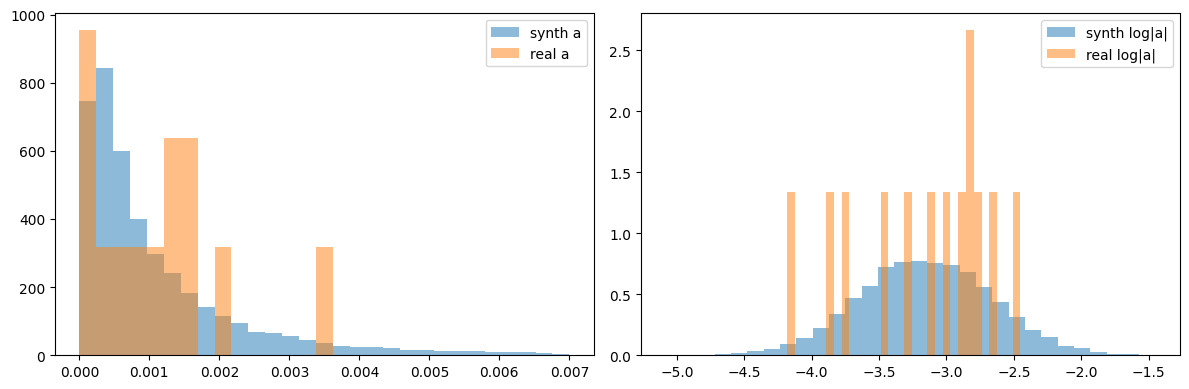

In [27]:
fig4, axs3 = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

bins_f1 = np.linspace(0, 0.007, 30)              # ASCENDING, positive (F1 has a>0)
axs3[0].hist(synth_a_f1, bins=bins_f1, alpha=0.5, density=True, label='synth a')
axs3[0].hist(a1,          bins=bins_f1, alpha=0.5, density=True, label='real a')

axs3[1].hist(np.log10(synth_a_f1), bins=30, alpha=0.5, density=True, label='synth log|a|')
axs3[1].hist(log_abs_a1,           bins=30, alpha=0.5, density=True, label='real log|a|')

axs3[0].legend(); axs3[1].legend()
plt.tight_layout()
plt.show()

In [28]:
f1.dropna().to_csv("./data/Real_F1_13.csv")

# Family 4 Event Generator

In [29]:
def sample_cdaw(n, rng):
    s, _ = gmm_cdaw.sample(n)
    s = np.asarray(s) * sd_cdaw + mu_cdaw                       # unstandardize: [speed, log_mass, width_deg]
    df = pd.DataFrame(s, columns=['v0_pos', 'log_mass', 'width_deg'])
    df['v0'] = 1.027 * df['v0_pos'] + 41.5            # POS -> de-projected (Napoletano T1 r24)
    df['mass'] = 10 ** df['log_mass']
    df['width_deg'] = df['width_deg'].clip(1, 359)    # guard halo degeneracy
    return df[['v0', 'mass', 'width_deg']].reset_index(drop=True)

def solve_TT_F4(a, v0, w, gamma, t_lo=1.0, t_hi=400*3600):
    # known a(<0), v0>w, gamma -> find t where r_F4(t)=1 AU. Returns HOURS or nan.
    g = lambda t: r_F4(t, a, v0, w, gamma) - AU
    try:
        glo, ghi = g(t_lo), g(t_hi)
    except (ValueError, FloatingPointError):
        return np.nan
    if not np.isfinite(glo) or not np.isfinite(ghi) or glo * ghi > 0:
        return np.nan                                 # no crossing -> invalid trajectory
    try:
        return brentq(g, t_lo, t_hi) / 3600.0
    except (ValueError, FloatingPointError):
        return np.nan


def generate_f4(n_target=10_000, oversample=10, seed=0):
    rng = np.random.default_rng(seed)
    n_draw = n_target * oversample

    cme = sample_cdaw(n_draw, rng)              # v0(de-proj), mass, width_deg
    env = sample_w_rho(n_draw)                  # w, rho (paired; filters internally)

    m = min(len(cme), len(env))                 # align (sample_w_rho drops some)
    df = pd.concat([cme.iloc[:m].reset_index(drop=True),
                    env.iloc[:m].reset_index(drop=True)], axis=1)

    df = df[df['v0'] > df['w']].reset_index(drop=True)          # F4 membership

    rw_vals = f4['rel_wid'].value_counts(normalize=True)
    df['rel_wid'] = rng.choice(rw_vals.index, size=len(df), p=rw_vals.values)
    df['A'] = np.pi * (r_0 * np.sin(df['rel_wid'] / 2.0))**2

    M_P, CM3_PER_KM3 = 1.6726e-24, 1e15
    rho_mass = df['rho'] * M_P * CM3_PER_KM3                    # protons/cm^3 -> g/km^3
    df['gamma'] = 100.0 * (df['A'] * rho_mass) / df['mass']     # C=100

    a_draw = -(10 ** rng.normal(mu_a, sd_a, len(df)))
    df['a'] = np.clip(a_draw, a.min(), a.max())                 # clip to observed F4 range

    df['TT'] = df.apply(lambda r: solve_TT_F4(r['a'], r['v0'], r['w'], r['gamma']), axis=1)
    df = df.dropna(subset=['TT']).reset_index(drop=True)        # drop invalid trajectories

    return df[['v0', 'mass', 'A', 'rho', 'w', 'gamma', 'a', 'TT']]


In [30]:
synth_f4 = generate_f4(10_000, oversample=10)
print("final synthetic F4 events:", len(synth_f4))
synth_f4.describe()

final synthetic F4 events: 40824


,v0,mass,A,rho,w,gamma,a,TT
count,40824.000000,4.082400e+04,4.082400e+04,40824.000000,40824.000000,4.082400e+04,40824.000000,40824.000000
mean,631.655667,2.057987e+15,1.502450e+14,6.341030,389.170479,2.574914e-06,-0.001917,121.023518
std,271.352040,6.430531e+15,4.562834e+13,3.170822,62.717431,3.117083e-05,0.001176,47.809408
min,235.473933,7.902376e+10,1.252313e+13,0.732195,184.575570,1.438274e-10,-0.004838,15.032338
25%,449.454858,1.931057e+14,8.907036e+13,4.063806,346.864753,6.672091e-08,-0.002502,95.213068
50%,550.926334,6.330812e+14,1.804145e+14,5.563765,383.286516,2.093157e-07,-0.001605,113.063089
75%,729.527481,1.917195e+15,1.804145e+14,7.841192,424.690049,6.953894e-07,-0.001032,135.459943
max,3076.207799,3.248081e+17,1.804145e+14,32.156645,777.339202,2.848586e-03,-0.000155,399.513809


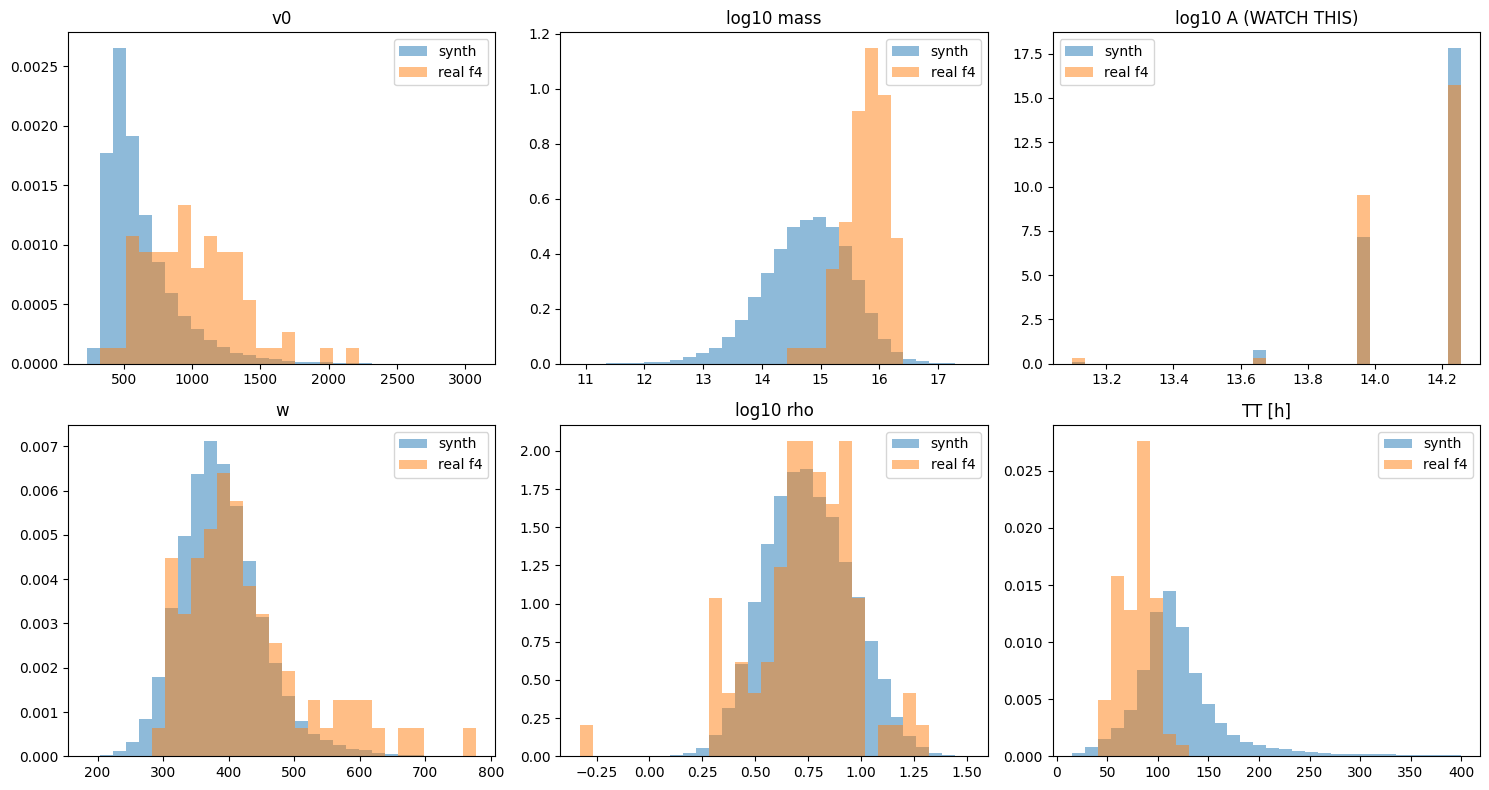

coupling ratio  synth: 0.29595069767493243  real: 0.3680759179708369


In [31]:
real = f4.loc[a.index]                              # solved real F4 events (have a, gamma)
real_TT = real['Transit_time'] / 3600.0            # f4 Transit_time is in SECONDS

pairs = [('v0', real['v_r'], 'v0'), ('mass', real['Mass'], 'mass'),
         ('A', real['A'], 'A (WATCH THIS)'), ('w', real['w'], 'w'),
         ('rho', real['rho'], 'rho'), ('TT', real_TT, 'TT [h]')]

fig_f4, ax_f4 = plt.subplots(2, 3, figsize=(15, 8))
for v, (col, real_vals, title) in enumerate(pairs):
    i, j = divmod(v, 3)
    logx = col in ('mass', 'A', 'rho')
    sv = np.log10(synth_f4[col]) if logx else synth_f4[col]
    rv = np.log10(real_vals)     if logx else real_vals
    b = np.histogram_bin_edges(np.concatenate([sv, rv]), bins=30)
    ax_f4[i, j].hist(sv, bins=b, density=True, alpha=.5, label='synth')
    ax_f4[i, j].hist(rv, bins=b, density=True, alpha=.5, label='real f4')
    ax_f4[i, j].set_title(('log10 ' if logx else '') + title)
    ax_f4[i, j].legend()
plt.tight_layout(); plt.show()

# coupling check: |a| / [gamma (v0-w)^2] must match real, order-unity
s_ratio = (-synth_f4['a']) / (synth_f4['gamma'] * (synth_f4['v0'] - synth_f4['w'])**2)
r_ratio = (-real['a'])     / (real['gamma']     * (real['v_r'] - real['w'])**2)
print("coupling ratio  synth:", s_ratio.median(), " real:", r_ratio.median())

In [32]:
synth_f4.to_csv("./data/Synthetic_F4_40k.csv")

# Family 1 Event Generator

In [33]:
def solve_TT_F1(a, v0, w, gamma, t_lo=1.0, t_hi=200*3600):
    g = lambda t: r_F1(t, a, v0, w, gamma) - AU
    try:
        glo, ghi = g(t_lo), g(t_hi)
    except (ValueError, FloatingPointError):
        return np.nan
    if not np.isfinite(glo) or not np.isfinite(ghi) or glo * ghi > 0:
        return np.nan
    try:
        return brentq(g, t_lo, t_hi) / 3600.0
    except (ValueError, FloatingPointError):
        return np.nan

def generate_f1(n_target=10_000, oversample=10, seed=0):
    rng = np.random.default_rng(seed)
    n_draw = n_target * oversample

    cme = sample_cdaw(n_draw, rng)              # v0(de-proj), mass, width_deg
    env = sample_w_rho(n_draw)                  # w, rho (paired; filters internally)

    m = min(len(cme), len(env))                 # align (sample_w_rho drops some)
    df = pd.concat([cme.iloc[:m].reset_index(drop=True),
                    env.iloc[:m].reset_index(drop=True)], axis=1)

    df = df[df['v0'] <= df['w']].reset_index(drop=True)          # F1 membership

    rw_vals = f1['rel_wid'].value_counts(normalize=True)
    df['rel_wid'] = rng.choice(rw_vals.index, size=len(df), p=rw_vals.values)
    df['A'] = np.pi * (r_0 * np.sin(df['rel_wid'] / 2.0))**2

    M_P, CM3_PER_KM3 = 1.6726e-24, 1e15
    rho_mass = df['rho'] * M_P * CM3_PER_KM3                    # protons/cm^3 -> g/km^3
    df['gamma'] = 100.0 * (df['A'] * rho_mass) / df['mass']     # C=100

    a1_draw = (10 ** rng.normal(mu_a1, sd_a1, len(df)))
    df['a'] = np.clip(a1_draw, a1.min(), a1.max())                 # clip to observed F1 range

    df['TT'] = df.apply(lambda r: solve_TT_F1(r['a'], r['v0'], r['w'], r['gamma']), axis=1)
    df = df.dropna(subset=['TT']).reset_index(drop=True)        # drop invalid trajectories

    return df[['v0', 'mass', 'A', 'rho', 'w', 'gamma', 'a', 'TT']]

In [34]:
synth_f1 = generate_f1(10_000, oversample=10)
print("final synthetic F1 events:", len(synth_f1))
synth_f1.describe()

C:\Users\Lukas\AppData\Local\Temp\ipykernel_4708\1377925042.py:9: RuntimeWarning: overflow encountered in exp
  e = np.exp(2 * (s*t - sigma))


final synthetic F1 events: 55499


,v0,mass,A,rho,w,gamma,a,TT
count,55499.000000,5.549900e+04,5.549900e+04,55499.000000,55499.000000,5.549900e+04,55499.000000,55499.000000
mean,276.482856,7.997470e+14,4.877426e+13,5.649597,474.457434,1.436695e-06,0.001069,81.759462
std,100.057821,3.195721e+15,1.735522e+13,3.110731,105.142172,9.781970e-06,0.001013,17.223094
min,-1145.865084,1.304483e+11,1.488397e+13,0.629041,200.435581,7.242591e-11,0.000066,42.769632
25%,215.684627,6.691823e+13,4.620937e+13,3.405680,390.278819,5.672128e-08,0.000320,68.569792
50%,276.033568,2.011760e+14,4.620937e+13,4.907419,455.658186,1.771728e-07,0.000680,80.048898
75%,336.224058,6.301110e+14,4.620937e+13,7.151057,553.697432,5.646327e-07,0.001467,92.811200
max,735.353195,2.806755e+17,8.907036e+13,35.646575,894.477590,7.761720e-04,0.003533,199.237144


In [36]:
check = synth_f1.apply(
    lambda r: r_F1(r['TT']*3600, r['a'], r['v0'], r['w'], r['gamma']) - AU, axis=1)
print("residual r_F1(TT)-AU:  max abs =", check.abs().max(), " (should be ~0, <~1e3 km)")

residual r_F1(TT)-AU:  max abs = 5.960464477539062e-07  (should be ~0, <~1e3 km)


In [37]:
synth_f1[synth_f1['v0'] > 0].to_csv("./data/Synthetic_F1_55k.csv")